# 📑 Project Phase 1: Business Understanding (CRISP-DM)

## 1. Background
In the modern fintech landscape, users face significant challenges in tracking their spending due to **cryptic, inconsistent, and unstructured bank transaction descriptions**. These raw transaction strings often lack meaningful context, making it difficult for users to understand where their money is going.

To enable better financial awareness, these transaction descriptions must be transformed into **clear, human-readable categories** such as *Dining, Utilities, Shopping,* and others. This transformation is essential for improving financial visibility and empowering users to make informed decisions.

---

## 2. Business Objectives

### 🔹 Automation  
Eliminate the need for manual expense categorization by developing a **Machine Learning-based classification system** that automatically assigns categories to transactions.

### 🔹 Insights  
Provide users with **actionable insights** into their spending behavior by generating clear and structured breakdowns of expenses, ultimately improving financial literacy.

### 🔹 Scalability  
Design a system capable of handling **new and unseen merchants** by leveraging linguistic patterns in transaction descriptions, ensuring adaptability in real-world scenarios.

---

## 3. Data Science Goals

### 🔹 Task  
Formulate the problem as a **multi-class text classification task**, where each transaction string is mapped to a predefined expense category.

### 🔹 NLP Pipeline  
Develop a robust Natural Language Processing (NLP) pipeline that includes:
- Text Cleaning  
- Tokenization  
- Lemmatization  

This ensures that noisy and unstructured text is converted into meaningful features for model training.

### 🔹 Performance Metric  
Target a **Weighted F1-Score greater than 0.90**, ensuring:
- Balanced performance across all categories  
- Accurate classification of minority classes (e.g., *Lifestyle*)  
- Avoidance of misleading high accuracy due to class imbalance (the *accuracy trap*)

---

## 4. Success Criteria

### 🔹 Technical Success  
The model achieves high precision and recall on a **hidden test dataset**, demonstrating strong generalization to unseen transaction descriptions.

### 🔹 Functional Success  
Users can input a raw transaction description into a **web-based interface (e.g., Streamlit)** and receive an **instant, accurate category prediction**, enabling real-time usability.

In [67]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [68]:
data = pd.read_excel('../Data/Raw/personal_transactions_dashboard_ready (2).xlsx')
data.head()

,Date,Description,Amount,Transaction Type,Category,Account Name,Month
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01
4,2018-01-04,Netflix,11.76,debit,Movies & Dvds,Platinum Card,2018-01


In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              806 non-null    datetime64[ns]
 1   Description       806 non-null    object        
 2   Amount            806 non-null    float64       
 3   Transaction Type  806 non-null    object        
 4   Category          806 non-null    object        
 5   Account Name      806 non-null    object        
 6   Month             806 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 44.2+ KB


In [70]:
data.isnull().sum()

Date                0
Description         0
Amount              0
Transaction Type    0
Category            0
Account Name        0
Month               0
dtype: int64

In [71]:
data.duplicated().sum()

np.int64(0)

In [72]:
data['Category'].value_counts()

Category
Credit Card Payment       143
Groceries                 105
Restaurants                81
Utilities                  63
Shopping                   60
Gas & Fuel                 52
Paycheck                   46
Home Improvement           36
Coffee Shops               31
Alcohol & Bars             25
Internet                   21
Mortgage & Rent            21
Mobile Phone               21
Music                      21
Movies & Dvds              18
Auto Insurance             18
Fast Food                  16
Haircut                    13
Television                  8
Electronics & Software      4
Food & Dining               2
Entertainment               1
Name: count, dtype: int64

In [73]:
mapping = {
    'Restaurants': 'Dining', 'Coffee Shops': 'Dining', 'Fast Food': 'Dining', 
    'Alcohol & Bars': 'Dining', 'Food & Dining': 'Dining',
    'Utilities': 'Bills_Utilities', 'Internet': 'Bills_Utilities', 
    'Mortgage & Rent': 'Bills_Utilities', 'Mobile Phone': 'Bills_Utilities',
    'Television': 'Bills_Utilities', 'Home Improvement': 'Bills_Utilities',
    'Music': 'Lifestyle', 'Movies & DVDs': 'Lifestyle', 'Haircut': 'Lifestyle', 'Entertainment': 'Lifestyle',
    'Electronics & Software': 'Lifestyle',
}

data['Master_Category'] = data['Category'].map(mapping).fillna(data['Category'])

In [74]:
data.head()

,Date,Description,Amount,Transaction Type,Category,Account Name,Month,Master_Category
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018-01,Shopping
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01,Bills_Utilities
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01,Dining
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01,Credit Card Payment
4,2018-01-04,Netflix,11.76,debit,Movies & Dvds,Platinum Card,2018-01,Movies & Dvds


In [75]:
data['Master_Category'].value_counts()

Master_Category
Bills_Utilities        170
Dining                 155
Credit Card Payment    143
Groceries              105
Shopping                60
Gas & Fuel              52
Paycheck                46
Lifestyle               39
Movies & Dvds           18
Auto Insurance          18
Name: count, dtype: int64

In [76]:
data['Description'].value_counts()

Description
Credit Card Payment      143
Grocery Store            103
Amazon                    59
Biweekly Paycheck         46
Hardware Store            34
                        ... 
Bakery Place               1
Vietnamese Restaurant      1
Target                     1
Hawaiian Grill             1
Sheetz                     1
Name: count, Length: 65, dtype: int64

In [77]:
# 1. Initialize the Vectorizer
# ngram_range=(1,2) means it looks at single words ("Netflix") 
# and pairs of words ("Zuku", "Fiber")
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500)

# 2. Transform the Text (X)
X = tfidf.fit_transform(data['Description']).toarray()

# 3. Transform the Categories (y)
label_enc = LabelEncoder()
y = label_enc.fit_transform(data['Master_Category'])

# 4. Split the Data
# We save 20% of the data to "test" the model later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"Ready to train on {len(X_train)} transactions!")

X_train shape: (644, 143)
Ready to train on 644 transactions!


In [78]:

# 1. Initialize the Model
model = LogisticRegression(max_iter=1000)
# 2. Train the Model
model.fit(X_train, y_train)
# 3. Predict on the Test Set
y_pred = model.predict(X_test)
# 4. Evaluate the Model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.96      0.90      0.93        30
           2       1.00      1.00      1.00        23
           3       0.89      1.00      0.94        32
           4       1.00      0.73      0.84        11
           5       1.00      1.00      1.00        21
           6       1.00      0.90      0.95        10
           7       0.50      0.80      0.62         5
           8       1.00      1.00      1.00         7
           9       1.00      0.95      0.97        20

    accuracy                           0.94       162
   macro avg       0.94      0.93      0.93       162
weighted avg       0.96      0.94      0.95       162

[[ 3  0  0  0  0  0  0  0  0  0]
 [ 0 27  0  0  0  0  0  3  0  0]
 [ 0  0 23  0  0  0  0  0  0  0]
 [ 0  0  0 32  0  0  0  0  0  0]
 [ 0  1  0  2  8  0  0  0  0  0]
 [ 0  0  0  0  0 21  0  0  0  0]
 [ 0  0  0  0  0  0  9  1  0  0]
 [ 0  0  0

In [79]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
# 1. Initialize the Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# 2. Train the Model
rf_model.fit(X_train, y_train)
# 3. Predict on the Test Set
rf_y_pred = rf_model.predict(X_test)
# 4. Evaluate the Model
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_y_pred))




Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      0.90      0.95        30
           2       1.00      1.00      1.00        23
           3       1.00      0.97      0.98        32
           4       0.85      1.00      0.92        11
           5       1.00      1.00      1.00        21
           6       1.00      0.90      0.95        10
           7       0.56      1.00      0.71         5
           8       1.00      1.00      1.00         7
           9       1.00      0.95      0.97        20

    accuracy                           0.96       162
   macro avg       0.94      0.97      0.95       162
weighted avg       0.98      0.96      0.97       162

Random Forest Confusion Matrix:
[[ 3  0  0  0  0  0  0  0  0  0]
 [ 0 27  0  0  0  0  0  3  0  0]
 [ 0  0 23  0  0  0  0  0  0  0]
 [ 0  0  0 31  1  0  0  0  0  0]
 [ 0  0  0  0 11  0  0  0  0  0]
 [ 0  0

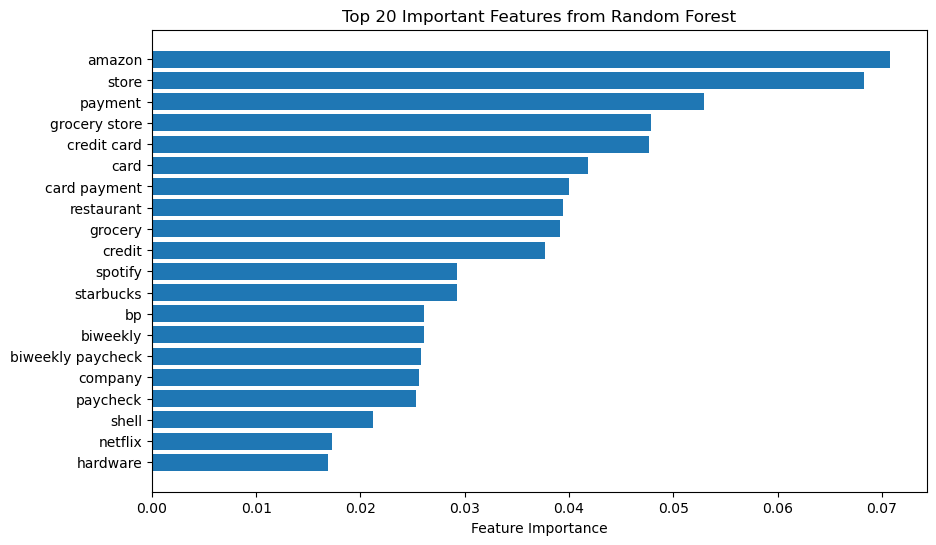

In [80]:
# Feature Importance from Random Forest

feature_importances = rf_model.feature_importances_
feature_names = tfidf.get_feature_names_out()
# Get top 20 features
top_indices = np.argsort(feature_importances)[-20:]
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_indices)), feature_importances[top_indices], align='center')
plt.yticks(range(len(top_indices)), [feature_names[i] for i in top_indices])
plt.xlabel('Feature Importance')
plt.title('Top 20 Important Features from Random Forest')
plt.show()

In [86]:
import pickle
import os

# 1. Define the path (Go up one level, then into models)
model_path = '../models/'

# 2. Create the folder if it doesn't exist (This ensures it's in the right spot)
if not os.path.exists(model_path):
    os.makedirs(model_path)

# 3. Save the Vectorizer
with open(os.path.join(model_path, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)

# 4. Save the Model
with open(os.path.join(model_path, 'rf_model.pkl'), 'wb') as f:
    pickle.dump(model, f)

# 5. Save the Label Encoder
with open(os.path.join(model_path, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_enc, f)

print(f"Success! Check your main project folder: {os.path.abspath(model_path)}")

Success! Check your main project folder: /home/khalid-abdulkadir/Documents/Fintech_Personal_finance/personal Finance/models
